## Artificial Intelligence Course — Spring 2026 – Kanan Sultanov 606.23E
Laboratory Work 2. Linear regression (10 points) (Demo 16.03.2026 and 18.03.2026)

In this task you need to apply linear regression using gradient descent method and numpy library for prediction of the strength of the concrete compressive using data from UCI machine learning repository

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%config InlineBackend.figure_format = 'retina'

In [2]:
concrete_compressive_strength = fetch_ucirepo(id=165) 

X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets 

Examine the dataset for missing values and columns of type object. If present, impute the missing values and convert object-type columns into numerical representations

In [3]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [4]:
X.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
dtype: int64

In [5]:
X.dtypes

Cement                float64
Blast Furnace Slag    float64
Fly Ash               float64
Water                 float64
Superplasticizer      float64
Coarse Aggregate      float64
Fine Aggregate        float64
Age                     int64
dtype: object

In [6]:
y

,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


In [7]:
y.isna().sum()

Concrete compressive strength    0
dtype: int64

In [8]:
#Convert input and ouptut values into numpy array
#Don’t forget to add a column to the beginning of the X array to simplify the calculation of sum(w·x) + b.

X = np.insert(X.to_numpy(), 0, 1, axis = 1)
y = y.to_numpy()

In [9]:
X

array([[1.000e+00, 5.400e+02, 0.000e+00, ..., 1.040e+03, 6.760e+02,
        2.800e+01],
       [1.000e+00, 5.400e+02, 0.000e+00, ..., 1.055e+03, 6.760e+02,
        2.800e+01],
       [1.000e+00, 3.325e+02, 1.425e+02, ..., 9.320e+02, 5.940e+02,
        2.700e+02],
       ...,
       [1.000e+00, 1.485e+02, 1.394e+02, ..., 8.924e+02, 7.800e+02,
        2.800e+01],
       [1.000e+00, 1.591e+02, 1.867e+02, ..., 9.896e+02, 7.889e+02,
        2.800e+01],
       [1.000e+00, 2.609e+02, 1.005e+02, ..., 8.645e+02, 7.615e+02,
        2.800e+01]])

In [10]:
X.shape

(1030, 9)

At this stage, the data can be scaled to improve model performance.

In [11]:
#Initialize the weights vector by setting all elements to zero or to any other chosen value
#In this case, remember to increase the size of the weights vector so that you can compute the result using a single dot product instead of w·x + b.

w = np.zeros(X.shape[1])

In [12]:
w

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
w.shape

(9,)

Split the dataset into two parts: training and testing. You can use train_test_split from the scikit-learn library.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

write the code for calculation of the function z = sum(x, w) 

In [15]:
#code for calculation of the z function

def z(x, w):
    return np.dot(x, w)

Implement code to calculate the Squared Loss function and output the loss over all training examples using the initial weight values

In [16]:
def squared_Loss(x, y, w):
    predictions = z(x, w)
    y_flat = y.flatten()
    return np.mean((predictions - y_flat) ** 2)

In [17]:
print(squared_Loss(X_train, y_train, w))

1588.987312066574


Write code to compute the gradient of the Squared Loss function with respect to the weight vector w

In [18]:
#Gradient of Squeared Loss function

def grad_SL(x, y, w):
    
    predictions = z(x, w)
    y_flat = y.flatten()
    errors = predictions - y_flat
    n = x.shape[0]
    gradient = (2 / n) * np.dot(x.T, errors)
    
    return gradient

In [19]:
print(grad_SL(X_train, y_train, w))

[   -72.30546463 -22371.1202552   -5845.88223578  -3466.49370874
 -12931.62993897   -519.49136477 -69956.3785742  -55392.57877947
  -4007.89065187]


Code for gradient descent algorithm

In [20]:
w = np.zeros(X_train.shape[1]) 

alpha = 1e-8 
iterations = 10001

print("Initial Loss:", squared_Loss(X_train, y_train, w))

for i in range(iterations):
    grad = grad_SL(X_train, y_train, w)
    w = w - (alpha * grad)
    loss = squared_Loss(X_train, y_train, w)
    
    if i % 1000 == 0:
        print(f"Iteration = {i}, Loss={loss}")

Initial Loss: 1588.987312066574
Iteration = 0, Loss=1503.515332841343
Iteration = 1000, Loss=252.29794984428202
Iteration = 2000, Loss=226.93820493118292
Iteration = 3000, Loss=209.20948599451927
Iteration = 4000, Loss=196.336567007091
Iteration = 5000, Loss=186.62648780448424
Iteration = 6000, Loss=179.03288398415768
Iteration = 7000, Loss=172.8988269636828
Iteration = 8000, Loss=167.80421782890778
Iteration = 9000, Loss=163.47464206223313
Iteration = 10000, Loss=159.72651315829822


In [21]:
w # optimal weight vector

array([ 3.74356793e-05,  8.07963852e-02,  4.68560624e-02,  1.19788571e-02,
       -1.20910765e-02,  7.25120698e-03,  8.40820555e-04,  1.06373933e-02,
        4.64838280e-02])

In [22]:
loss # minimum value of loss

np.float64(159.72651315829822)

Assess the performance of the linear regression model using appropriate evaluation metrics

In [23]:
y_pred = z(X_test, w)

In [24]:
print("R2_score: ", r2_score(y_test, y_pred))

R2_score:  0.3961929884588702


A task from the passive syllabus that is not included in the active syllabus

In [25]:
#Determine the most important feature based on the values of the optimal weights vector

np.abs(w).max()

np.float64(0.08079638518763274)

In [26]:
np.argmax(np.abs(w)) # index of the most important feature, it is Blast Furnace Slag

np.int64(1)

Based on the identified feature, apply polynomial regression with polynomial degrees from 2 to 8. Train each model using the gradient descent algorithm on the training dataset, determine the optimal weight vector, and evaluate the performance of the resulting models on the test dataset. Graphical representations of the results can be provided to enhance interpretability and support model explanation.

In [27]:
train_losses = []
test_losses = []

x_train_single = X_train[:, 1].reshape(-1, 1)
x_test_single = X_test[:, 1].reshape(-1, 1)

degrees = list(range(2, 9))
train_losses = []

for d in degrees:
    
    poly = PolynomialFeatures(degree = d, include_bias=False)
    X_train_poly = poly.fit_transform(x_train_single)
    X_test_poly = poly.transform(x_test_single)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_loss = mean_squared_error(y_train, y_train_pred)
    test_loss = mean_squared_error(y_test, y_test_pred)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    print(f"Degree {d}: Train Loss = {train_loss:.2f}, Test Loss = {test_loss:.2f}")

Degree 2: Train Loss = 212.36, Test Loss = 203.73
Degree 3: Train Loss = 212.33, Test Loss = 203.92
Degree 4: Train Loss = 212.18, Test Loss = 203.48
Degree 5: Train Loss = 212.36, Test Loss = 204.28
Degree 6: Train Loss = 212.19, Test Loss = 205.16
Degree 7: Train Loss = 211.93, Test Loss = 205.90
Degree 8: Train Loss = 211.80, Test Loss = 206.54


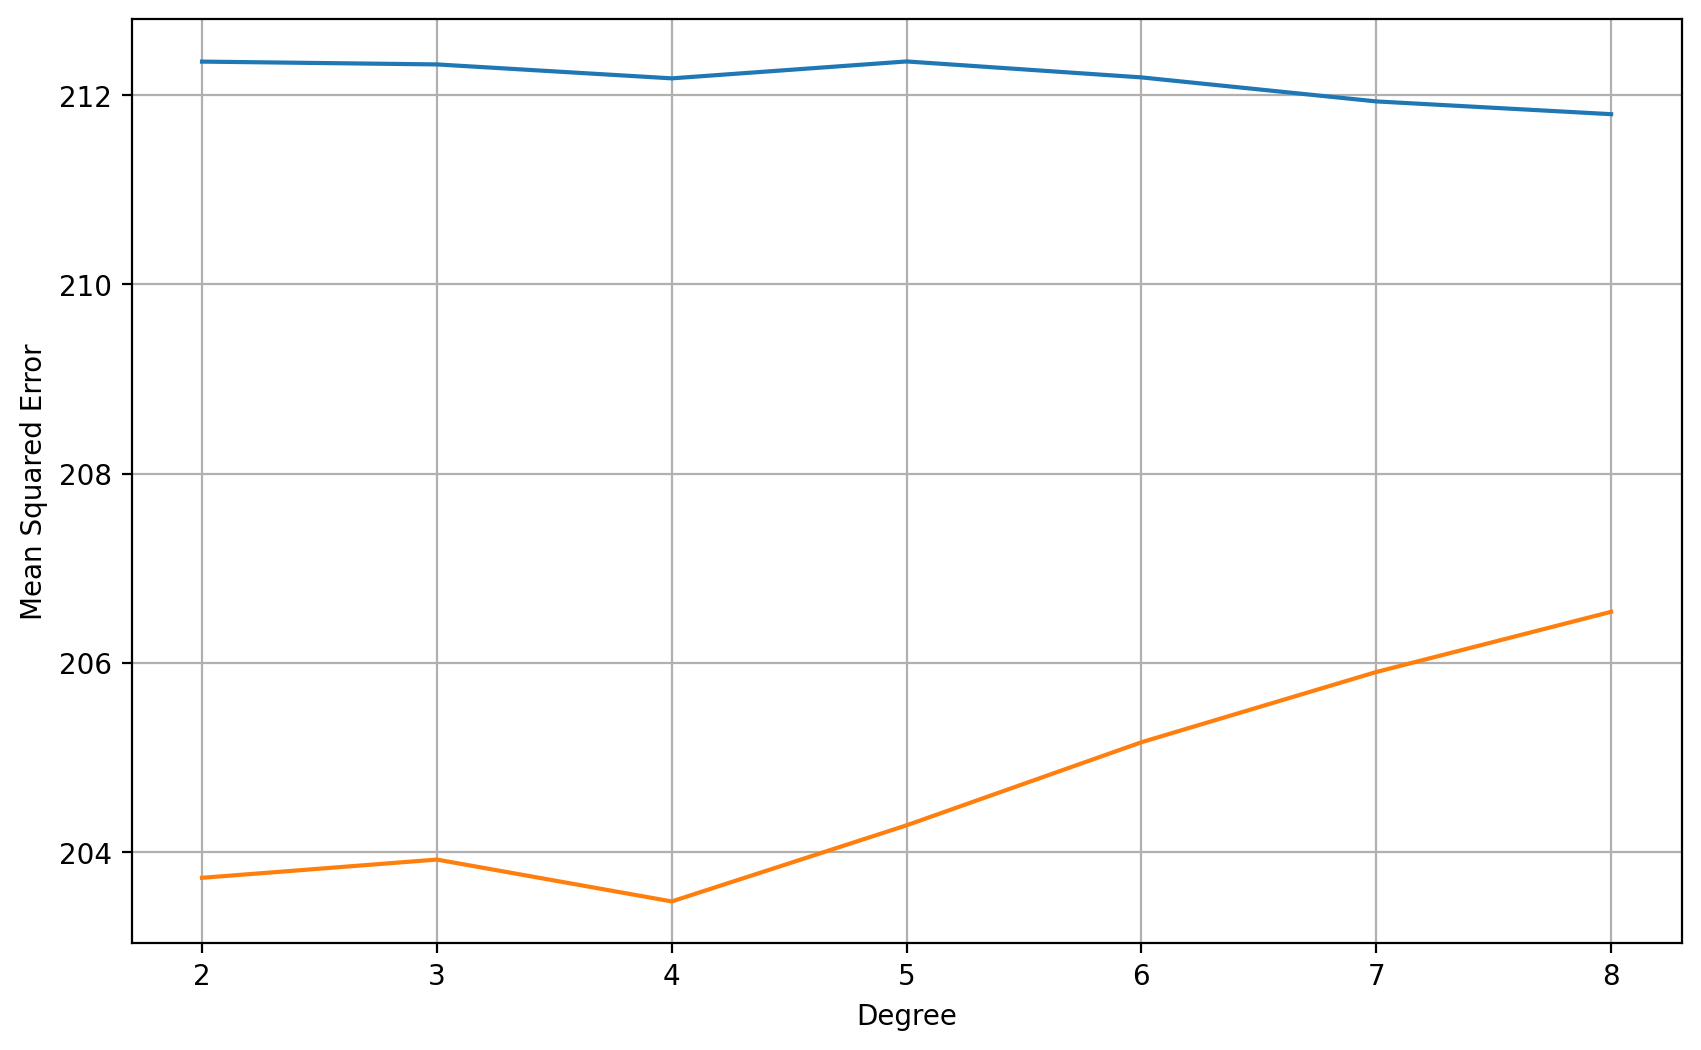

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_losses, label='Train Loss')
plt.plot(degrees, test_losses, label='Test Loss')
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.xticks(degrees)
plt.grid(True)
plt.show()

Identify the polynomial degrees at which the model exhibits underfitting and overfitting, and provide a clear explanation of your conclusions.

## Answer
The model finds an ideal balance at the 4th degree, where the test error reaches its absolute minimum (203.48). However, from the 5th to the 8th degree, clear overfitting occurs: the training error continues to drop while the test error steadily increases (up to 206.54). This indicates that the overly complex model is memorizing random noise in the training data, losing its ability to accurately generalize to new, unseen patients.